In [25]:
import os
import numpy as np
import librosa
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


In [26]:
def extract_features(file_path, n_mfcc=13, hop_length=256):
    try:
        audio, sample_rate = librosa.load(file_path, sr=None)
        n_fft = min(len(audio), 512)
        
        mfcc = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length)
        mfcc_features = np.mean(mfcc.T, axis=0)
        return mfcc_features
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

In [28]:
paths = {
    'Amlou': r"C:\Users\dell\Data Science\Food Recognation\Tamazight_Project\Data_Tamazight\Amlou_wav",
    'Ourkimen': r"C:\Users\dell\Data Science\Food Recognation\Tamazight_Project\Data_Tamazight\Ourkimen_wav",
    'Tagala': r"C:\Users\dell\Data Science\Food Recognation\Tamazight_Project\Data_Tamazight\Tagla_wav"
}
data = []
labels = []

for label, folder in paths.items():
    print(f"Processing folder: {label}")
    for file in os.listdir(folder):
        file_path = os.path.join(folder, file)
        features = extract_features(file_path)
        if features is not None:
            data.append(features)
            labels.append(label)


Processing folder: Amlou


c:\Users\dell\AppData\Local\Programs\Python\Python310\lib\site-packages\librosa\feature\spectral.py:2143: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)


Processing folder: Ourkimen
Processing folder: Tagala


In [29]:
data = np.array(data)
labels = np.array(labels)

print(f"Data shape: {data.shape}")
print(f"Number of samples per class: {dict(zip(paths.keys(), [labels.tolist().count(label) for label in paths.keys()]))}")

Data shape: (3848, 13)
Number of samples per class: {'Amlou': 1352, 'Ourkimen': 1288, 'Tagala': 1208}


In [30]:
scaler = StandardScaler()
data = scaler.fit_transform(data)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


c:\Users\dell\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
540 fits failed out of a total of 1620.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
98 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\dell\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\dell\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py", line 1466, in wrapper
    estimator._validate_params()
  File "c:\Users\dell\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py"

Test Accuracy: 0.84
Classification Report:
              precision    recall  f1-score   support

       Amlou       0.80      0.84      0.82       270
    Ourkimen       0.89      0.87      0.88       258
      Tagala       0.85      0.82      0.84       242

    accuracy                           0.84       770
   macro avg       0.85      0.84      0.84       770
weighted avg       0.85      0.84      0.84       770



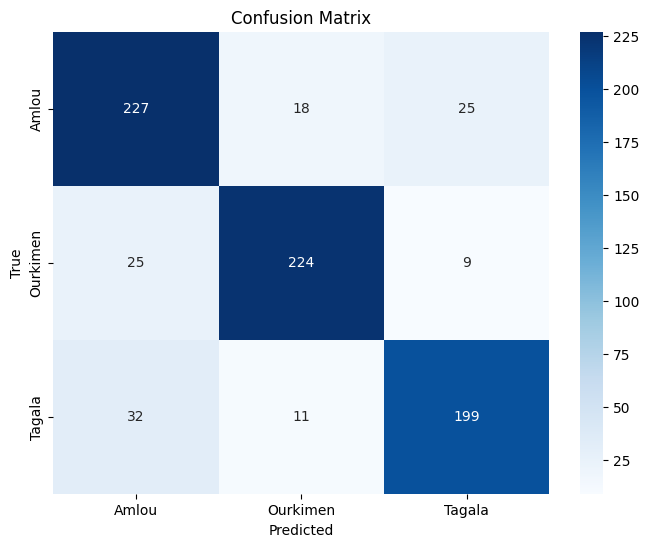

Error processing V1\amlou_laila_V1.wav: [Errno 2] No such file or directory: 'V1\\amlou_laila_V1.wav'
File: V1\ourkimen_laiala_V1.wav -> Predicted Label: Ourkimen
File: V1\tagala_laila_V1.wav -> Predicted Label: Tagala


C:\Users\dell\AppData\Local\Temp\ipykernel_60572\3953943438.py:3: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sample_rate = librosa.load(file_path, sr=None)
c:\Users\dell\AppData\Local\Programs\Python\Python310\lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
c:\Users\dell\AppData\Local\Programs\Python\Python310\lib\site-packages\librosa\feature\spectral.py:2143: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)
c:\Users\dell\AppData\Local\Programs\Python\Python310\lib\site-packages\librosa\feature\spectral.py:2143: UserWarning: Empty filters detected in mel frequency basis. Some channels will pr

In [31]:
import json
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib

# Encode labels
encoder = LabelEncoder()
encoded_labels = encoder.fit_transform(labels)
joblib.dump(encoder, "encoder.joblib")

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(data, encoded_labels, test_size=0.2, stratify=encoded_labels, random_state=42)

# Compute class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))

# Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

# Initialize and perform grid search
rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Retrieve the best model
best_rf_model = grid_search.best_estimator_

# Save the best model and the scaler
joblib.dump(best_rf_model, "best_random_forest_model.joblib")

# Save all parameters and evaluations
all_results = grid_search.cv_results_
parameters_and_scores = []

for i in range(len(all_results['params'])):
    param = all_results['params'][i]
    mean_score = all_results['mean_test_score'][i]
    std_score = all_results['std_test_score'][i]
    parameters_and_scores.append({
        'parameters': param,
        'mean_accuracy': mean_score,
        'std_accuracy': std_score
    })

# Save the results to a JSON file
model_info = {
    'best_parameters': grid_search.best_params_,
    'best_score': grid_search.best_score_,
    'training_accuracy': accuracy_score(y_train, best_rf_model.predict(X_train)),
    'test_accuracy': accuracy_score(y_test, best_rf_model.predict(X_test)),
    'parameters_and_scores': parameters_and_scores
}

with open("model_info.json", "w") as f:
    json.dump(model_info, f, indent=4)

# Evaluate the model
y_test_pred = best_rf_model.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred):.2f}")
print("Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=encoder.classes_))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Prediction for new test files
test_files = [
    r"V1\amlou_laila_V1.wav",
    r"V1\ourkimen_laiala_V1.wav",
    r"V1\tagala_laila_V1.wav"
]

def predict_new_files(test_files):
    for file in test_files:
        features = extract_features(file)
        if features is not None:
            # Normalize the feature
            features = scaler.transform([features])
            
            # Predict the label
            prediction = best_rf_model.predict(features)
            predicted_label = encoder.inverse_transform(prediction)
            print(f"File: {file} -> Predicted Label: {predicted_label[0]}")

predict_new_files(test_files)


In [32]:
predict_new_files(test_files)

Error processing V1\amlou_laila_V1.wav: [Errno 2] No such file or directory: 'V1\\amlou_laila_V1.wav'
File: V1\ourkimen_laiala_V1.wav -> Predicted Label: Ourkimen
File: V1\tagala_laila_V1.wav -> Predicted Label: Tagala


C:\Users\dell\AppData\Local\Temp\ipykernel_60572\3953943438.py:3: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sample_rate = librosa.load(file_path, sr=None)
c:\Users\dell\AppData\Local\Programs\Python\Python310\lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
c:\Users\dell\AppData\Local\Programs\Python\Python310\lib\site-packages\librosa\feature\spectral.py:2143: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)
c:\Users\dell\AppData\Local\Programs\Python\Python310\lib\site-packages\librosa\feature\spectral.py:2143: UserWarning: Empty filters detected in mel frequency basis. Some channels will pr